# Bell States Use Case

This notebook compiles Bell-state models with the LEQO backend and executes the resulting circuits with Qiskit.

## Workflow

1. Load model JSON files from this folder.
2. Send each model to `POST /debug/compile`.
3. Capture the returned OpenQASM.
4. Execute with Qiskit Aer and inspect measurement histograms.

In [4]:
import json
from pathlib import Path

import requests
from IPython.display import display
from qiskit import QuantumCircuit, qasm3, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [ ]:
BASE_URL = "http://localhost:8000"
COMPILE_URL = f"{BASE_URL}/debug/compile"

USE_CASE_DIR = Path.cwd()
if not (USE_CASE_DIR / "bell_phi_plus.json").exists():
    USE_CASE_DIR = Path("/01-bell-states")

MODEL_FILES = [
    USE_CASE_DIR / "bell_phi_plus.json",
    USE_CASE_DIR / "bell_phi_minus.json",
    USE_CASE_DIR / "bell_psi_plus.json",
    USE_CASE_DIR / "bell_psi_minus.json",
]
MODEL_FILES

In [6]:
def compile_model(model_path: Path) -> tuple[dict, str]:
    payload = json.loads(model_path.read_text(encoding="utf-8"))
    response = requests.post(COMPILE_URL, json=payload, timeout=120)
    response.raise_for_status()

    content_type = response.headers.get("content-type", "")
    if "application/json" in content_type:
        raise RuntimeError(f"Unexpected JSON response: {response.json()}")

    return payload, response.text


compiled_models: dict[str, dict] = {}
for model_path in MODEL_FILES:
    payload, qasm_text = compile_model(model_path)
    compiled_models[model_path.stem] = {"payload": payload, "qasm": qasm_text}
    print(f"{model_path.name}: {len(qasm_text.splitlines())} QASM lines")

bell_phi_plus.json: 19 QASM lines
bell_phi_minus.json: 20 QASM lines
bell_psi_plus.json: 20 QASM lines
bell_psi_minus.json: 21 QASM lines


In [7]:
sample_name = next(iter(compiled_models))
print(f"Sample OpenQASM from {sample_name}:")
print("\n".join(compiled_models[sample_name]["qasm"].splitlines()[:40]))

Sample OpenQASM from bell_phi_plus:
OPENQASM 3.1;
include "stdgates.inc";
qubit[2] leqo_reg;
/* Start node prepare */
let leqo_aa3a7f547f5f5337872930f6b38a8308_state = leqo_reg[{0, 1}];
h leqo_aa3a7f547f5f5337872930f6b38a8308_state[0];
cx leqo_aa3a7f547f5f5337872930f6b38a8308_state[0], leqo_aa3a7f547f5f5337872930f6b38a8308_state[1];
@leqo.output 0
let leqo_aa3a7f547f5f5337872930f6b38a8308_state_out = leqo_aa3a7f547f5f5337872930f6b38a8308_state;
/* End node prepare */
/* Start node measure */
@leqo.input 0
let leqo_4983cc78a037571ca3ca46051929624b_q = leqo_reg[{0, 1}];
bit[2] leqo_4983cc78a037571ca3ca46051929624b_result = measure leqo_4983cc78a037571ca3ca46051929624b_q[{0, 1}];
@leqo.output 0
let leqo_4983cc78a037571ca3ca46051929624b_out = leqo_4983cc78a037571ca3ca46051929624b_result;
@leqo.output 1
let leqo_4983cc78a037571ca3ca46051929624b_qubit_out = leqo_4983cc78a037571ca3ca46051929624b_q;
/* End node measure */


## Execute with Qiskit

In [8]:
def circuit_from_qasm(qasm_text: str) -> QuantumCircuit:
    qc = qasm3.loads(qasm_text)
    return qc


bell_phi_plus | counts={'00 ': 2047, '11 ': 2049}


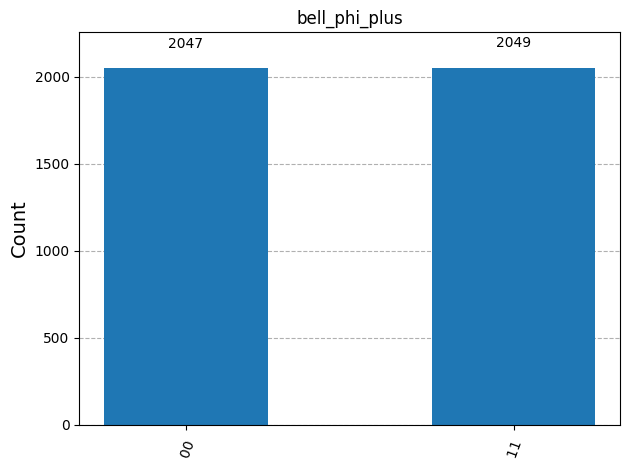

bell_phi_minus | counts={'00 ': 2038, '11 ': 2058}


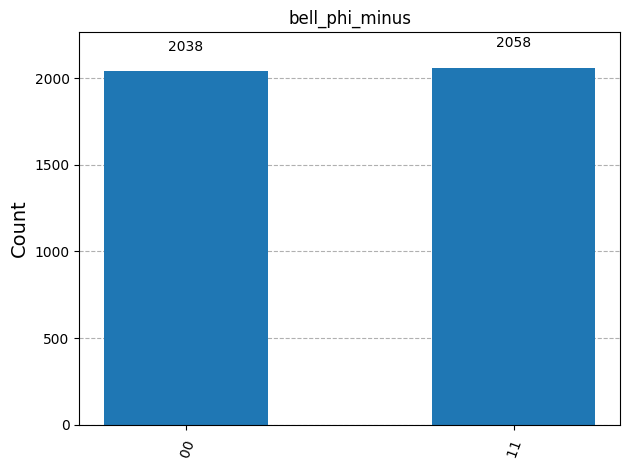

bell_psi_plus | counts={'01 ': 2015, '10 ': 2081}


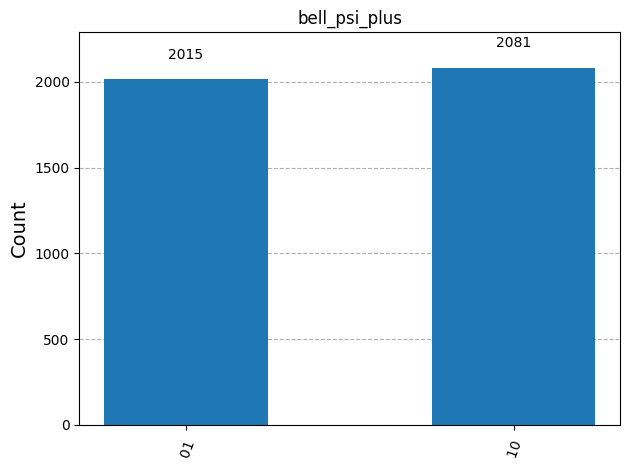

bell_psi_minus | counts={'01 ': 2046, '10 ': 2050}


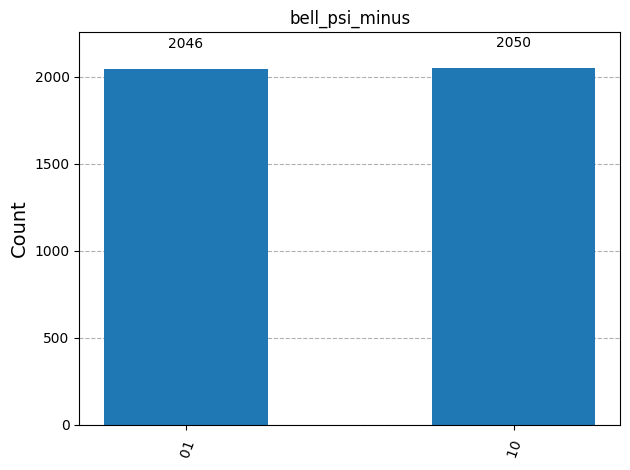

In [9]:
simulator = AerSimulator()
shots = 4096
counts_by_model: dict[str, dict[str, int]] = {}

for name, artifact in compiled_models.items():
    qc = circuit_from_qasm(artifact["qasm"])
    tqc = transpile(qc, simulator)
    counts = simulator.run(tqc, shots=shots).result().get_counts()
    counts_by_model[name] = counts

    print(f"{name} | counts={counts}")
    display(plot_histogram(counts, title=name))


In [10]:
for name, counts in counts_by_model.items():
    total = sum(counts.values())
    normalized = {k: round(v / total, 4) for k, v in sorted(counts.items())}
    print(f"{name}: {normalized}")

bell_phi_plus: {'00 ': 0.4998, '11 ': 0.5002}
bell_phi_minus: {'00 ': 0.4976, '11 ': 0.5024}
bell_psi_plus: {'01 ': 0.4919, '10 ': 0.5081}
bell_psi_minus: {'01 ': 0.4995, '10 ': 0.5005}


Expected dominant basis states:

- `bell_phi_plus`: `00`, `11`
- `bell_phi_minus`: `00`, `11`
- `bell_psi_plus`: `01`, `10`
- `bell_psi_minus`: `01`, `10`